In [5]:
!pip install tensorflow

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [6]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Load Fashion-MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model on GPU
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_classes))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_classes))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1780462277.731893     288 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14476 MB memory:  -> device: 0, name: NVIDIA H200 MIG 1g.18gb, pci bus id: 0000:61:00.0, compute capability: 9.0a
E0000 00:00:1780462278.128926     954 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.6.77, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Epoch 1/10


I0000 00:00:1780462279.599186     942 service.cc:153] XLA service 0x7fecc8044250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780462279.599209     942 service.cc:161]   StreamExecutor [0]: NVIDIA H200 MIG 1g.18gb, Compute Capability 9.0a (Driver: 12.8.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.5.0)
I0000 00:00:1780462279.615944     942 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780462279.766466     942 cuda_dnn.cc:461] Loaded cuDNN version 90500
I0000 00:00:1780462279.817968     942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1659__.16


 36/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3753 - loss: 1.7468

I0000 00:00:1780462285.247571     942 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7744 - loss: 0.6309 - val_accuracy: 0.8537 - val_loss: 0.4103
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8467 - loss: 0.4260 - val_accuracy: 0.8619 - val_loss: 0.3796
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8617 - loss: 0.3822 - val_accuracy: 0.8648 - val_loss: 0.3651
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8694 - loss: 0.3570 - val_accuracy: 0.8778 - val_loss: 0.3352
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8751 - loss: 0.3397 - val_accuracy: 0.8763 - val_loss: 0.3403
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8798 - loss: 0.3244 - val_accuracy: 0.8842 - val_loss: 0.3230
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8825 - loss: 0.3147 - val_accuracy: 0.8808 - val_loss: 0.3328
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8857 - loss: 0.3039 - val_accuracy: 0.8832 - va

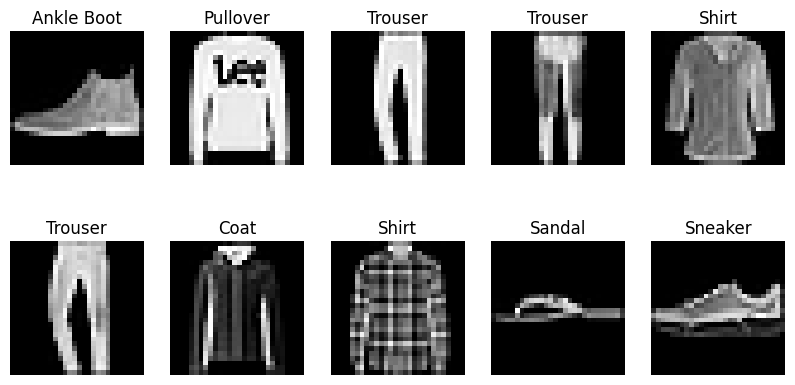

In [8]:
class_names = [
    'T-shirt','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag','Ankle Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()